# Real Estate Price Prediction in India  
### Bangalore/Pune-focused study aim with full-dataset benchmarking

This notebook builds an end-to-end, **sklearn-compatible** property price prediction pipeline for the uploaded Indian real-estate listings dataset.

## Study aim

**Primary objective:** predict property prices (`price`) for Indian residential listings, with special attention to **Bangalore** and **Pune**.

Because the uploaded dataset contains only a **small number of Bangalore + Pune rows**, the notebook does two things:

1. **Reports Bangalore/Pune-specific descriptive insights**, and  
2. **Uses the full dataset for stable cross-validated model benchmarking by default**.

You can flip one switch later if you want to force modeling on Bangalore + Pune only.

## What this notebook covers

- Data loading and schema audit
- Missing-value handling and hidden-missingness detection
- Outlier detection and practical treatment
- Feature engineering from `size`, `date`, `type`, and `neighborhood`
- Exploratory data analysis
- Model development and comparison:
  - Linear Regression
  - Ridge Regression
  - Lasso Regression
  - Decision Tree Regressor
  - Random Forest Regressor
- Cross-validated comparison using:
  - RMSE
  - MAE
  - R²
  - fit time / score time
- Final best-model evaluation and interpretation

In [2]:
# If you are running this in a fresh environment, uncomment the next line:
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib jupyter

import re
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

In [3]:
# -------------------------------
# Configuration
# -------------------------------

DATA_PATH = Path("data/raw/real_estate_dataset.csv")   # change if needed
TARGET_CITIES = ["Bangalore", "Pune"]

# IMPORTANT:
# Bangalore + Pune alone has very few rows in this dataset.
# For a more stable 5-model comparison, this is kept False by default.
USE_ONLY_TARGET_CITIES_FOR_MODELING = False

# Relative date strings such as "1mo ago" are interpreted relative to this scrape date.
REFERENCE_DATE = pd.Timestamp("2025-02-19")

# Output folders
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATA_PATH.resolve())
print("Using only Bangalore/Pune for modeling:", USE_ONLY_TARGET_CITIES_FOR_MODELING)
print("Reference date for relative timestamps:", REFERENCE_DATE.date())

Dataset path: C:\Users\garim\OneDrive\Desktop\Real-Estate-Price-Drivers-Analysis\notebooks\data\raw\real_estate_dataset.csv
Using only Bangalore/Pune for modeling: False
Reference date for relative timestamps: 2025-02-19


## 1. Load the data

In [5]:
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
display(df_raw.head())

Shape: (287, 9)


,url,beds,city,date,size,type,baths,price,neighborhood
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,2025-02-19,799-1258 sqft,Residential land / Plot,0,2317000.0,Jigani
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,2025-02-19,1085 sqft,2 BHK Flat,2,12500000.0,Tumkur Road
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,2025-02-19,1525-2150 sqft,"3, 4 BHK Apartment",0,23200000.0,Whitefield
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,2025-02-19,658-1003 sqft,"2, 3 BHK Apartment",0,889000.0,Soukya Road
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,2025-02-19,1179-1449 sqft,"2, 3 BHK Apartment",0,6483000.0,Kalkere


In [6]:
display(pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_count": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean() * 100).round(2).values
}))

,column,dtype,missing_count,missing_pct
0,url,str,0,0.0
1,beds,int64,0,0.0
2,city,str,0,0.0
3,date,str,0,0.0
4,size,str,0,0.0
5,type,str,0,0.0
6,baths,int64,0,0.0
7,price,float64,0,0.0
8,neighborhood,str,0,0.0


## 2. Initial observations

The raw file has these columns:

- `url`
- `beds`
- `city`
- `date`
- `size`
- `type`
- `baths`
- `price`
- `neighborhood`

This means the analysis should focus on:

- parsing `size` into numeric square-foot features,
- parsing `date` into listing recency,
- handling `0` values in `beds` / `baths`,
- engineering cleaner location/type features,
- and carefully avoiding leakage from target-derived variables during modeling.

In [7]:
print("City counts:")
display(df_raw["city"].value_counts().to_frame("listing_count"))

focus_df_raw = df_raw[df_raw["city"].isin(TARGET_CITIES)].copy()
print(f"Rows for {TARGET_CITIES}: {len(focus_df_raw)}")
display(focus_df_raw["city"].value_counts().to_frame("listing_count"))

City counts:


,listing_count
city,
Kakinada,37
Visakhapatnam,25
Noida,22
Hyderabad,20
Chennai,20
Mumbai,17
Bangalore,10
Gurgaon,10
Kochi,10


Rows for ['Bangalore', 'Pune']: 19


,listing_count
city,
Bangalore,10
Pune,9


**Why full-dataset benchmarking is the default:**  
The dataset has only a small number of Bangalore/Pune rows, so using only those rows would make model comparison unstable.  
That is why the notebook keeps Bangalore/Pune as the **study focus** for descriptive insights, but uses the **full dataset** for cross-validated benchmarking unless you explicitly switch it off.

## 3. Helper functions for cleaning and feature engineering

In [8]:
def normalize_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip()

def parse_size_range(size_value):
    '''
    Converts strings like:
    - "1085 sqft"
    - "799-1258 sqft"
    - "967.58 - 1,751.41 sqft"
    - "0 sqft"
    - "Varies"
    into (min_sqft, max_sqft, mean_sqft)
    '''
    if pd.isna(size_value):
        return pd.Series([np.nan, np.nan, np.nan])

    s = str(size_value).strip().lower()
    hidden_missing_tokens = {"varies", "not specified", "na", "n/a", "none", ""}

    if s in hidden_missing_tokens:
        return pd.Series([np.nan, np.nan, np.nan])

    s = s.replace(",", "")
    nums = re.findall(r"\d*\.?\d+", s)

    if len(nums) == 0:
        return pd.Series([np.nan, np.nan, np.nan])

    nums = [float(n) for n in nums]

    if len(nums) == 1:
        val = nums[0]
        if val <= 0:
            return pd.Series([np.nan, np.nan, np.nan])
        return pd.Series([val, val, val])

    min_val = min(nums[0], nums[1])
    max_val = max(nums[0], nums[1])

    if min_val <= 0 or max_val <= 0:
        return pd.Series([np.nan, np.nan, np.nan])

    return pd.Series([min_val, max_val, (min_val + max_val) / 2.0])


def parse_listing_date(date_value, reference_date=REFERENCE_DATE):
    '''
    Handles:
    - "2025-02-19"
    - "2025-02-19T04:38:38.179Z"
    - "1mo ago", "2w ago", "4d ago", "Yesterday"
    '''
    if pd.isna(date_value):
        return pd.NaT

    s = str(date_value).strip()

    if s.lower() == "yesterday":
        return reference_date - pd.Timedelta(days=1)

    relative_match = re.match(r"^(\d+)\s*(d|w|mo)\s*ago$", s.lower())
    if relative_match:
        qty = int(relative_match.group(1))
        unit = relative_match.group(2)

        if unit == "d":
            return reference_date - pd.Timedelta(days=qty)
        elif unit == "w":
            return reference_date - pd.Timedelta(weeks=qty)
        elif unit == "mo":
            return reference_date - pd.Timedelta(days=30 * qty)

    parsed = pd.to_datetime(s, errors="coerce", utc=True)
    if pd.isna(parsed):
        parsed = pd.to_datetime(s, errors="coerce")

    if pd.isna(parsed):
        return pd.NaT

    if getattr(parsed, "tzinfo", None) is not None:
        parsed = parsed.tz_convert(None)

    return pd.Timestamp(parsed)


def derive_property_group(type_value):
    if pd.isna(type_value):
        return "Other"

    s = str(type_value).lower()

    if "plot" in s or "land" in s:
        return "Plot"
    if "villa" in s:
        return "Villa"
    if "builder floor" in s:
        return "Builder Floor"
    if "independent house" in s or "house" in s:
        return "Independent House"
    if "apartment" in s:
        return "Apartment"
    if "flat" in s:
        return "Flat"
    return "Other"


def bucket_rare_categories(series, min_count=3, other_label="Other"):
    vc = series.value_counts(dropna=False)
    keep = vc[vc >= min_count].index
    return series.where(series.isin(keep), other_label)


class DataFrameQuantileClipper(BaseEstimator, TransformerMixin):
    '''
    Clips numeric columns to training-set quantile bounds.
    This is a gentle outlier treatment that keeps rows instead of dropping too many.
    '''
    def __init__(self, columns=None, lower_q=0.01, upper_q=0.99):
        self.columns = columns
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X = X.copy()
        self.bounds_ = {}
        cols = self.columns if self.columns is not None else X.select_dtypes(include=np.number).columns.tolist()
        self.columns_ = cols

        for col in cols:
            if col in X.columns:
                non_null = pd.to_numeric(X[col], errors="coerce")
                self.bounds_[col] = (
                    non_null.quantile(self.lower_q),
                    non_null.quantile(self.upper_q)
                )
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lo, hi) in self.bounds_.items():
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce").clip(lo, hi)
        return X

## 4. Cleaning and feature engineering

In [9]:
df = df_raw.copy()

# Basic normalization
for col in ["city", "type", "neighborhood", "url", "size", "date"]:
    df[col] = df[col].apply(normalize_text)

# Parse size into numeric components
df[["size_min_sqft", "size_max_sqft", "size_mean_sqft"]] = df["size"].apply(parse_size_range)

# Parse dates
df["listing_date"] = df["date"].apply(parse_listing_date)
df["listing_age_days"] = (REFERENCE_DATE - df["listing_date"]).dt.days

# Property groups
df["property_group"] = df["type"].apply(derive_property_group)

# 0-bedroom and 0-bath entries are treated as structurally missing / unusable numeric values
# instead of true 0-room homes, especially because plots also exist in the data.
df["beds_clean"] = df["beds"].replace({0: np.nan})
df["baths_clean"] = df["baths"].replace({0: np.nan})

# Neighborhood bucketing for sparse categories
df["neighborhood_bucket"] = bucket_rare_categories(df["neighborhood"], min_count=3)

# Analysis-only feature (NOT used for prediction because it uses the target)
df["price_per_sqft"] = df["price"] / df["size_mean_sqft"]

df.head()

,url,beds,city,date,size,type,baths,price,neighborhood,size_min_sqft,size_max_sqft,size_mean_sqft,listing_date,listing_age_days,property_group,beds_clean,baths_clean,neighborhood_bucket,price_per_sqft
0,https://www.99acres.com/residential-land-plot-...,0,Bangalore,2025-02-19,799-1258 sqft,Residential land / Plot,0,2317000.0,Jigani,799.0,1258.0,1028.5,2025-02-19,0,Plot,NaN,NaN,Other,2252.795333
1,https://www.99acres.com/2-bhk-bedroom-apartmen...,2,Bangalore,2025-02-19,1085 sqft,2 BHK Flat,2,12500000.0,Tumkur Road,1085.0,1085.0,1085.0,2025-02-19,0,Flat,2.0,2.0,Other,11520.737327
2,https://www.99acres.com/sumadhura-capitol-resi...,3,Bangalore,2025-02-19,1525-2150 sqft,"3, 4 BHK Apartment",0,23200000.0,Whitefield,1525.0,2150.0,1837.5,2025-02-19,0,Apartment,3.0,NaN,Other,12625.850340
3,https://www.99acres.com/provident-botanico-sou...,2,Bangalore,2025-02-19,658-1003 sqft,"2, 3 BHK Apartment",0,889000.0,Soukya Road,658.0,1003.0,830.5,2025-02-19,0,Apartment,2.0,NaN,Other,1070.439494
4,https://www.99acres.com/kvg-superior-kalkere-b...,2,Bangalore,2025-02-19,1179-1449 sqft,"2, 3 BHK Apartment",0,6483000.0,Kalkere,1179.0,1449.0,1314.0,2025-02-19,0,Apartment,2.0,NaN,Other,4933.789954


In [10]:
data_quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "duplicate_url_rows",
        "non_positive_price_rows",
        "beds_equal_0",
        "baths_equal_0",
        "unparsed_size_rows",
        "unparsed_date_rows"
    ],
    "value": [
        len(df),
        df.shape[1],
        int(df["url"].duplicated().sum()),
        int((df["price"] <= 0).sum()),
        int((df["beds"] == 0).sum()),
        int((df["baths"] == 0).sum()),
        int(df["size_mean_sqft"].isna().sum()),
        int(df["listing_date"].isna().sum())
    ]
})

display(data_quality_summary)
data_quality_summary.to_csv(TABLE_DIR / "data_quality_summary.csv", index=False)

,metric,value
0,rows,287
1,columns,19
2,duplicate_url_rows,7
3,non_positive_price_rows,6
4,beds_equal_0,74
5,baths_equal_0,128
6,unparsed_size_rows,52
7,unparsed_date_rows,0


In [11]:
missing_report = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "dtype": df.dtypes.astype(str).values
}).sort_values(by="missing_pct", ascending=False)

display(missing_report)
missing_report.to_csv(TABLE_DIR / "missing_value_report.csv", index=False)

,column,missing_count,missing_pct,dtype
16,baths_clean,128,44.60,float64
15,beds_clean,74,25.78,float64
9,size_min_sqft,52,18.12,float64
18,price_per_sqft,52,18.12,float64
11,size_mean_sqft,52,18.12,float64
10,size_max_sqft,52,18.12,float64
0,url,0,0.00,str
2,city,0,0.00,str
1,beds,0,0.00,int64
3,date,0,0.00,str


### Notes on missing data

There are two kinds of missingness here:

1. **Literal missing values** (`NaN`)
2. **Hidden missingness**, for example:
   - `beds = 0`
   - `baths = 0`
   - `size = 0 sqft` or unparseable text
   - relative/odd `date` strings

For the modeling stage, we let sklearn handle missing numeric/categorical values using **unsupervised imputation**:
- numeric → median imputation
- categorical → most-frequent imputation

## 5. Outlier detection and practical treatment

We flag suspicious records for audit, but we do **not aggressively drop rows** because the dataset is already small.

### What we do
- remove only impossible rows for modeling (`price <= 0`)
- treat invalid size values as missing and impute them
- use a **quantile clipper** inside the modeling pipeline to reduce the influence of extreme numeric values

### What we also inspect for analysis
- extreme `price_per_sqft`
- duplicate URLs
- impossible prices
- impossible sizes

In [12]:
suspicious_mask = (
    df["url"].duplicated(keep=False)
    | (df["price"] <= 0)
    | (df["size_mean_sqft"].isna())
)

# IQR-based extreme price-per-sqft flag for audit only
pps = df["price_per_sqft"].replace([np.inf, -np.inf], np.nan).dropna()
q1, q3 = pps.quantile([0.25, 0.75])
iqr = q3 - q1
pps_low, pps_high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
extreme_pps_mask = df["price_per_sqft"].between(pps_low, pps_high, inclusive="both") == False
extreme_pps_mask = extreme_pps_mask.fillna(False)

df["flag_extreme_price_per_sqft"] = extreme_pps_mask
suspicious_mask = suspicious_mask | extreme_pps_mask

suspicious_records = df[suspicious_mask].copy()

print("Suspicious record count:", len(suspicious_records))
display(suspicious_records[[
    "city", "neighborhood", "type", "beds", "baths", "size", "price",
    "size_mean_sqft", "price_per_sqft", "flag_extreme_price_per_sqft", "url"
]].head(20))

suspicious_records.to_csv(TABLE_DIR / "suspicious_records.csv", index=False)

Suspicious record count: 85


,city,neighborhood,type,beds,baths,size,price,size_mean_sqft,price_per_sqft,flag_extreme_price_per_sqft,url
7,Bangalore,Hebbal,"4, 5 BHK Villa",4,0,0 sqft,39800000.0,NaN,NaN,True,https://www.99acres.com/keya-life-by-the-lake-...
10,Gurgaon,Sector 65,4 BHK Flat,4,4,6050 sqft,200000000.0,6050.000,33057.851240,True,https://www.99acres.com/4-bhk-bedroom-apartmen...
12,Gurgaon,Rosewood City,Residential land / Plot,0,0,9000 sqft,249500000.0,9000.000,27722.222222,True,https://www.99acres.com/residential-land-plot-...
13,Gurgaon,Sector 49,3 BHK Apartment,3,0,"967.58 - 1,751.41 sqft",52800000.0,1359.495,38837.950857,True,https://www.99acres.com/godrej-aristocrat-sect...
14,Gurgaon,Sector 49,4 BHK Apartment,4,5,1942 sqft,69000000.0,1942.000,35530.381050,True,https://www.99acres.com/4-bhk-bedroom-apartmen...
20,Kakinada,Atchampeta,Luxury Villa,3,5,2600 sqft,16500000.0,2600.000,6346.153846,False,https://www.99acres.com/3-bhk-bedroom-independ...
21,Kakinada,Kovvada,Luxury Villa,3,2,1800 sqft,11600000.0,1800.000,6444.444444,False,https://www.99acres.com/3-bhk-bedroom-independ...
22,Kakinada,Vakalapudi,Luxury Villa,4,6,165 sqft,10000000.0,165.000,60606.060606,True,https://www.99acres.com/4-bhk-bedroom-independ...
23,Kakinada,Sasikanth Nagar,Luxury Villa,5,5,2304 sqft,20000000.0,2304.000,8680.555556,False,https://www.99acres.com/5-bhk-bedroom-independ...
24,Kakinada,Sasikanth Nagar,Luxury Villa,4,5,230 sqft,20000000.0,230.000,86956.521739,True,https://www.99acres.com/4-bhk-bedroom-independ...


## 6. Exploratory data analysis

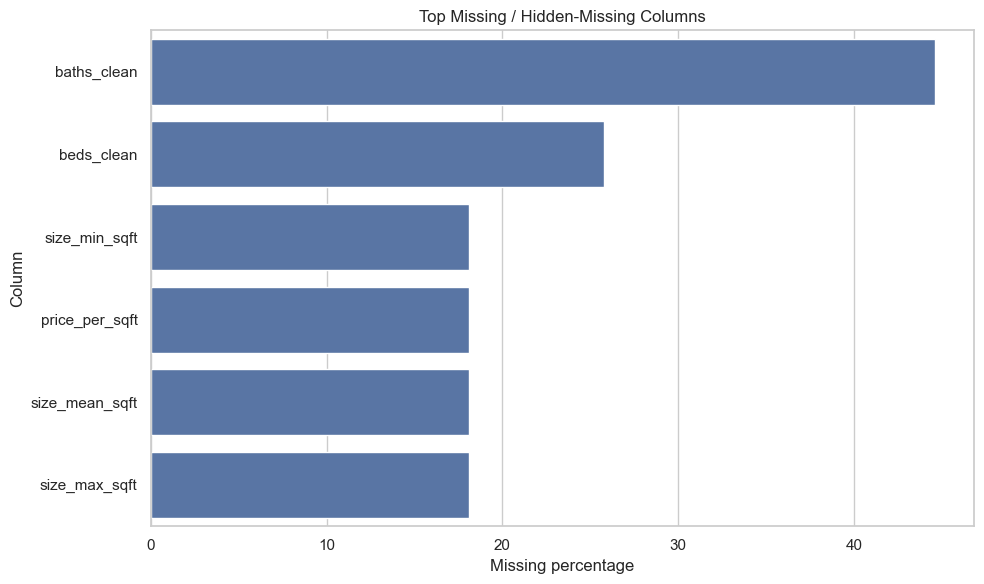

In [13]:
# Missing values bar chart
top_missing = missing_report[missing_report["missing_count"] > 0].head(15)

if len(top_missing) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_missing, x="missing_pct", y="column")
    plt.title("Top Missing / Hidden-Missing Columns")
    plt.xlabel("Missing percentage")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

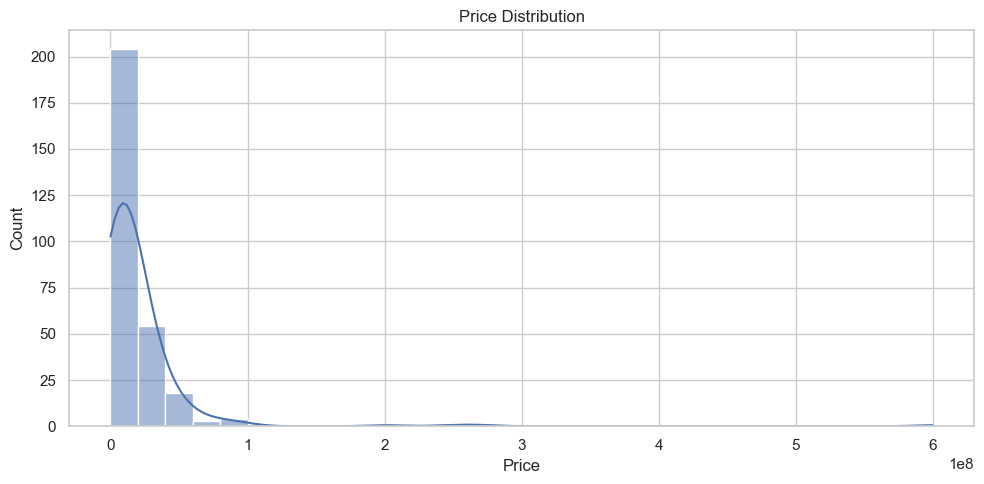

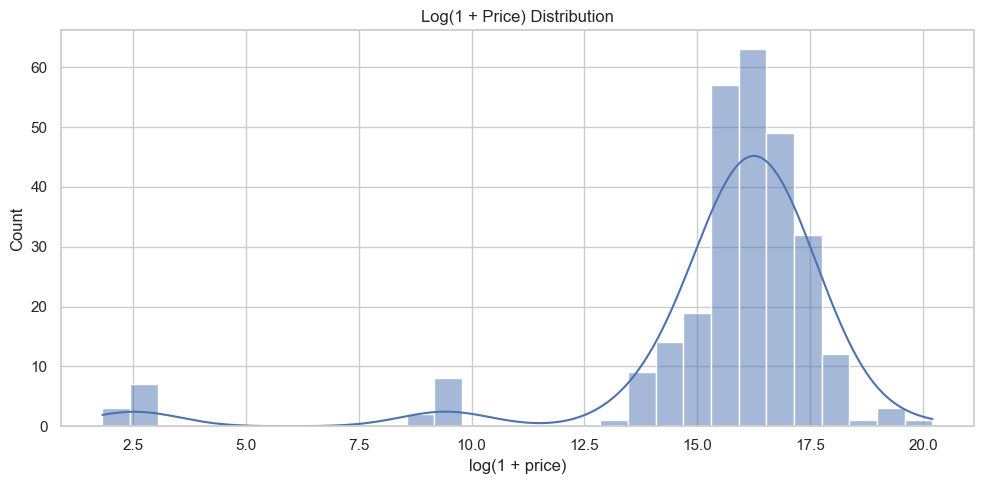

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df.loc[df["price"] > 0, "price"]), bins=30, kde=True)
plt.title("Log(1 + Price) Distribution")
plt.xlabel("log(1 + price)")
plt.tight_layout()
plt.show()

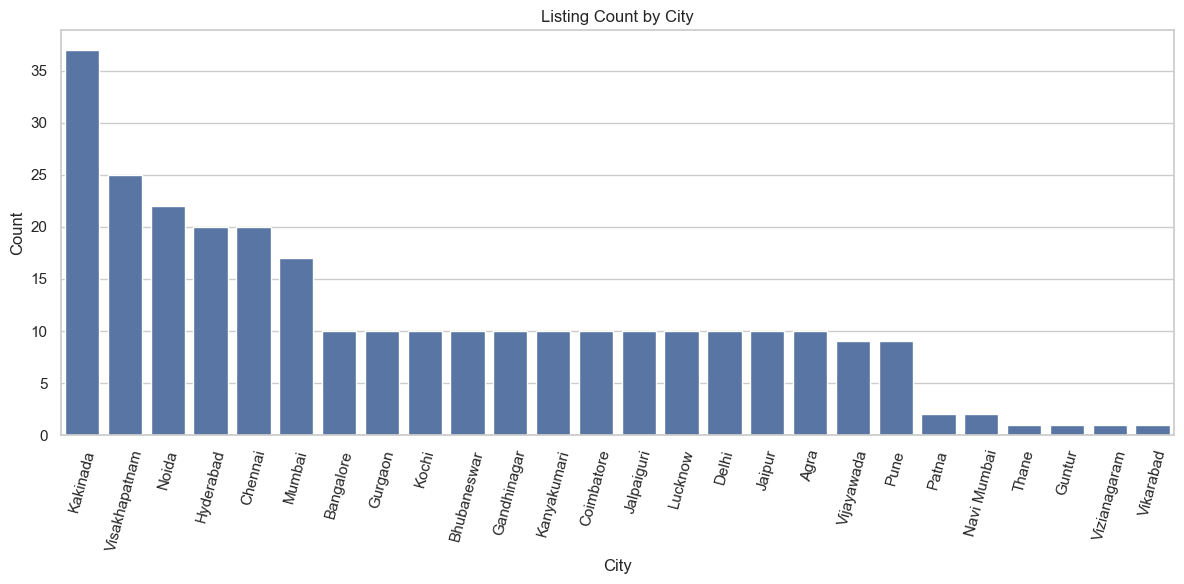

In [15]:
city_counts = df["city"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=city_counts.index, y=city_counts.values)
plt.title("Listing Count by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

,city,median_price
0,Gurgaon,44950000.0
1,Delhi,21750000.0
2,Noida,20500000.0
3,Vikarabad,20000000.0
4,Agra,18000000.0
5,Kakinada,16500000.0
6,Vizianagaram,16000000.0
7,Mumbai,14400000.0
8,Lucknow,11979500.0
9,Bangalore,11800000.0


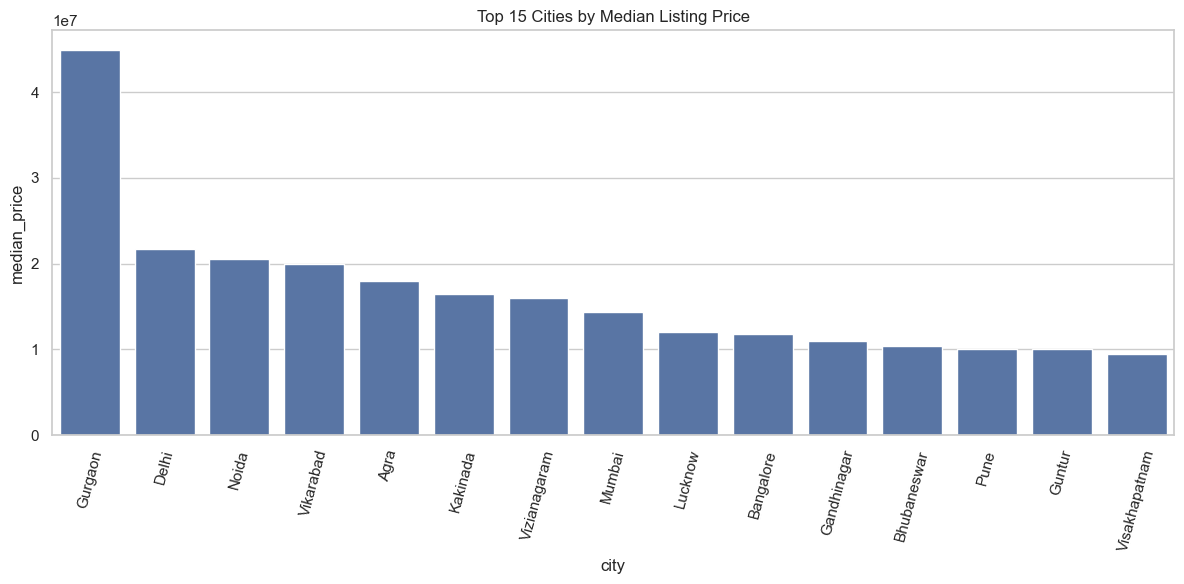

In [16]:
median_price_by_city = (
    df.groupby("city")["price"]
      .median()
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={"price": "median_price"})
)

display(median_price_by_city.head(15))
median_price_by_city.to_csv(TABLE_DIR / "median_price_by_city.csv", index=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=median_price_by_city.head(15), x="city", y="median_price")
plt.title("Top 15 Cities by Median Listing Price")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

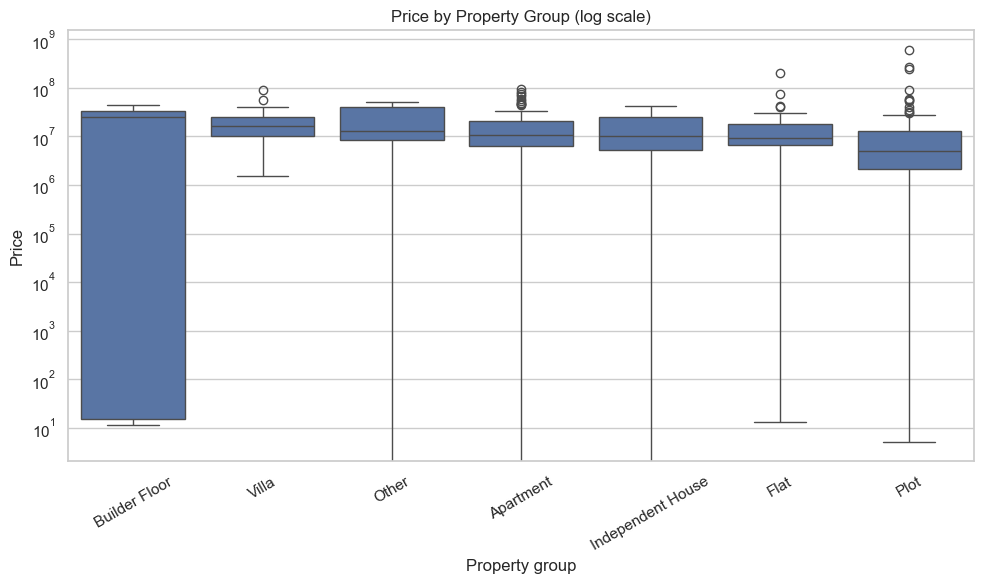

In [17]:
plt.figure(figsize=(10, 6))
group_order = df.groupby("property_group")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="property_group", y="price", order=group_order)
plt.yscale("log")
plt.title("Price by Property Group (log scale)")
plt.xlabel("Property group")
plt.ylabel("Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

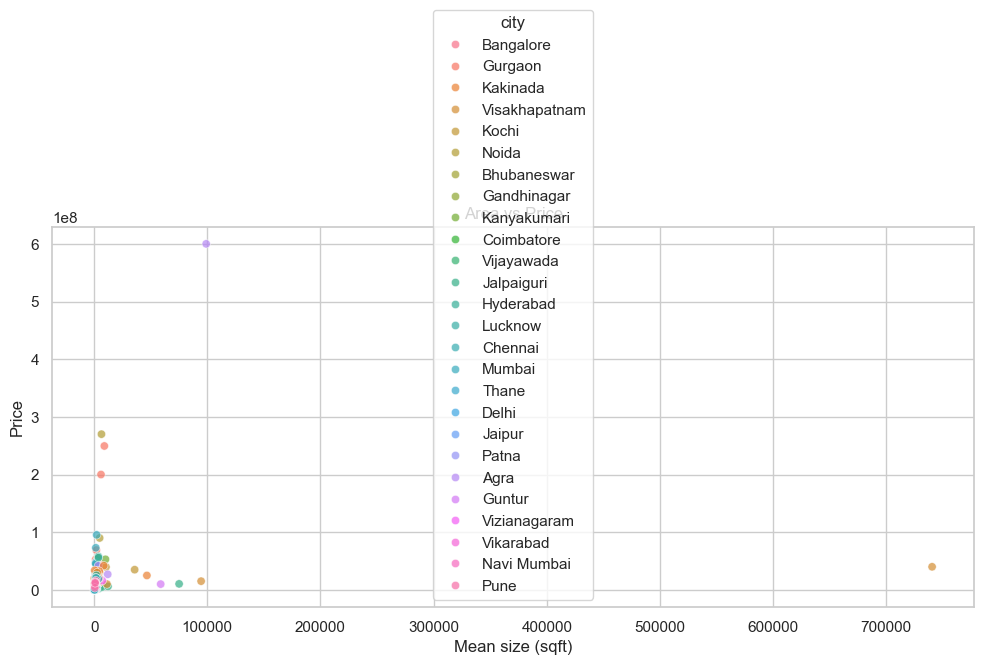

In [18]:
eda_scatter = df[(df["size_mean_sqft"].notna()) & (df["price"] > 0)].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_scatter, x="size_mean_sqft", y="price", hue="city", alpha=0.7)
plt.title("Area vs Price")
plt.xlabel("Mean size (sqft)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

Focused descriptive view for ['Bangalore', 'Pune']


,city,listings,median_price,median_size_sqft,median_price_per_sqft
0,Bangalore,10,11800000.0,1321.0,7781.908302
1,Pune,9,10000000.0,840.0,11904.761905


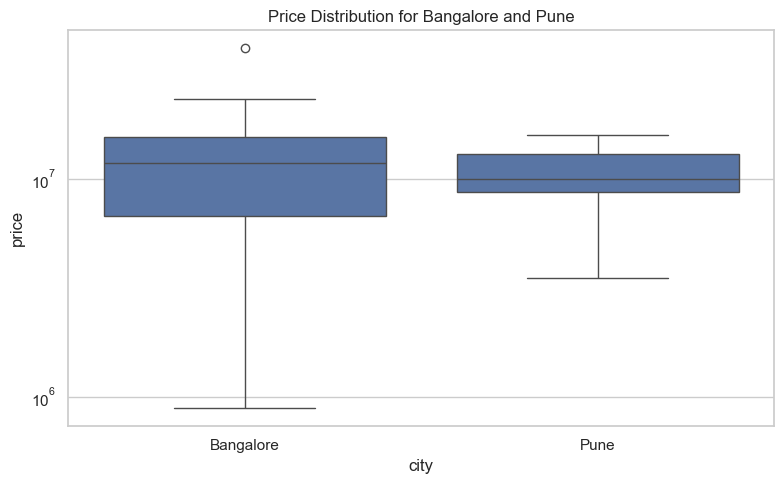

In [19]:
focus_df = df[df["city"].isin(TARGET_CITIES)].copy()

if len(focus_df) > 0:
    print(f"Focused descriptive view for {TARGET_CITIES}")
    display(
        focus_df.groupby("city")
                .agg(
                    listings=("price", "size"),
                    median_price=("price", "median"),
                    median_size_sqft=("size_mean_sqft", "median"),
                    median_price_per_sqft=("price_per_sqft", "median")
                )
                .reset_index()
    )

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=focus_df, x="city", y="price")
    plt.yscale("log")
    plt.title("Price Distribution for Bangalore and Pune")
    plt.tight_layout()
    plt.show()

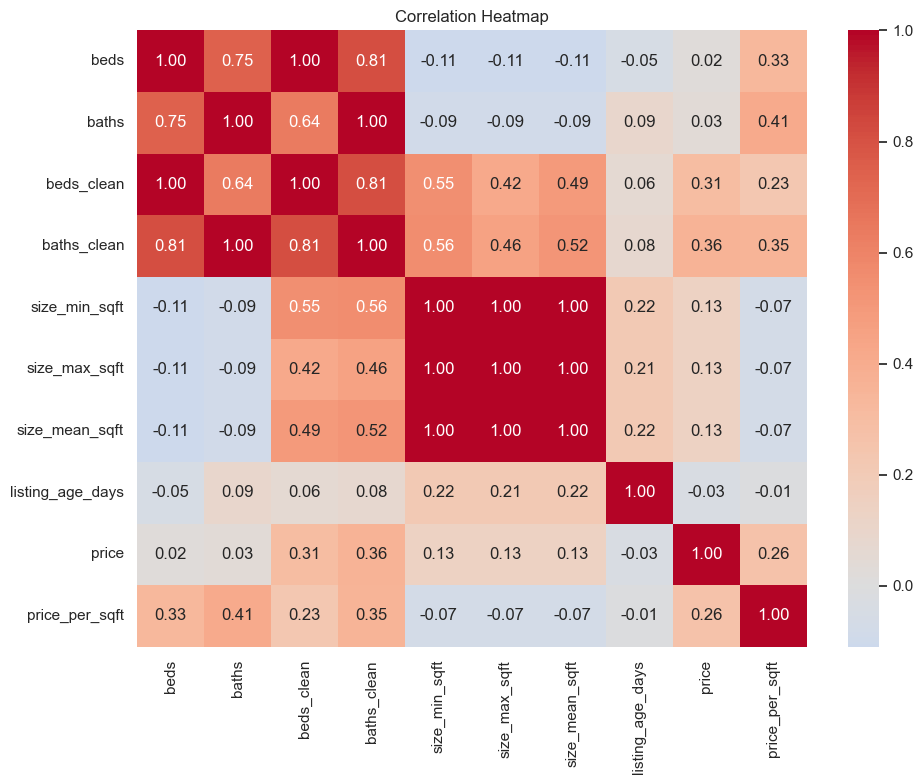

In [20]:
numeric_cols_for_corr = ["beds", "baths", "beds_clean", "baths_clean", "size_min_sqft", "size_max_sqft", "size_mean_sqft", "listing_age_days", "price", "price_per_sqft"]
corr_df = df[numeric_cols_for_corr].copy()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 7. Prepare the modeling dataset

### Important leakage rule
We **do not** use `price_per_sqft` as a model feature because it is derived from the target (`price`), which would leak target information into the predictors.

### Features used for modeling
- cleaned bedroom / bathroom counts
- city
- type
- property group
- neighborhood bucket
- size features
- listing age

In [21]:
model_df = df.copy()

# Optional city filter
if USE_ONLY_TARGET_CITIES_FOR_MODELING:
    model_df = model_df[model_df["city"].isin(TARGET_CITIES)].copy()

# Remove impossible target rows only
model_df = model_df[model_df["price"] > 0].copy()

feature_cols = [
    "beds_clean",
    "baths_clean",
    "city",
    "type",
    "property_group",
    "neighborhood_bucket",
    "size_min_sqft",
    "size_max_sqft",
    "size_mean_sqft",
    "listing_age_days"
]

target_col = "price"

X = model_df[feature_cols].copy()
y = model_df[target_col].copy()

print("Modeling rows:", len(X))
print("Modeling columns:", list(X.columns))
display(X.head())

Modeling rows: 281
Modeling columns: ['beds_clean', 'baths_clean', 'city', 'type', 'property_group', 'neighborhood_bucket', 'size_min_sqft', 'size_max_sqft', 'size_mean_sqft', 'listing_age_days']


,beds_clean,baths_clean,city,type,property_group,neighborhood_bucket,size_min_sqft,size_max_sqft,size_mean_sqft,listing_age_days
0,NaN,NaN,Bangalore,Residential land / Plot,Plot,Other,799.0,1258.0,1028.5,0
1,2.0,2.0,Bangalore,2 BHK Flat,Flat,Other,1085.0,1085.0,1085.0,0
2,3.0,NaN,Bangalore,"3, 4 BHK Apartment",Apartment,Other,1525.0,2150.0,1837.5,0
3,2.0,NaN,Bangalore,"2, 3 BHK Apartment",Apartment,Other,658.0,1003.0,830.5,0
4,2.0,NaN,Bangalore,"2, 3 BHK Apartment",Apartment,Other,1179.0,1449.0,1314.0,0


In [22]:
numeric_features = ["beds_clean", "baths_clean", "size_min_sqft", "size_max_sqft", "size_mean_sqft", "listing_age_days"]
categorical_features = ["city", "type", "property_group", "neighborhood_bucket"]

numeric_preprocessor_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_preprocessor_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(transformers=[
    ("num", numeric_preprocessor_scaled, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ("num", numeric_preprocessor_tree, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

clipper_columns = numeric_features

## 8. Build sklearn-compatible pipelines

In [23]:
def make_model_pipeline(model_name):
    model_name = model_name.lower().strip()

    if model_name == "linear regression":
        base_model = LinearRegression()
        preprocessor = preprocessor_scaled

    elif model_name == "ridge regression":
        base_model = Ridge(alpha=1.0, random_state=42)
        preprocessor = preprocessor_scaled

    elif model_name == "lasso regression":
        base_model = Lasso(alpha=0.001, max_iter=20000, random_state=42)
        preprocessor = preprocessor_scaled

    elif model_name == "decision tree":
        base_model = DecisionTreeRegressor(
            max_depth=8,
            min_samples_split=6,
            min_samples_leaf=3,
            random_state=42
        )
        preprocessor = preprocessor_tree

    elif model_name == "random forest":
        base_model = RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
        preprocessor = preprocessor_tree

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    pipeline = Pipeline(steps=[
        ("clipper", DataFrameQuantileClipper(columns=clipper_columns, lower_q=0.01, upper_q=0.99)),
        ("preprocessor", preprocessor),
        ("model", base_model)
    ])

    # Log-transform the target for more stable regression on skewed prices
    full_estimator = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.log1p,
        inverse_func=np.expm1
    )
    return full_estimator


model_names = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression",
    "Decision Tree",
    "Random Forest"
]

models = {name: make_model_pipeline(name) for name in model_names}
models

{'Linear Regression': TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                            regressor=Pipeline(steps=[('clipper',
                                                       DataFrameQuantileClipper(columns=['beds_clean',
                                                                                         'baths_clean',
                                                                                         'size_min_sqft',
                                                                                         'size_max_sqft',
                                                                                         'size_mean_sqft',
                                                                                         'listing_age_days'])),
                                                      ('preprocessor',
                                                       ColumnTransformer(transformers=[('num',
                             

## 9. Cross-validated model comparison

We compare models using:

- **RMSE** (lower is better)
- **MAE** (lower is better)
- **R²** (higher is better)
- **fit time** (lower is better)
- **score time** (lower is better)

A 5-fold shuffled KFold split is used for reproducibility.

In [25]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

comparison_rows = []

for name, estimator in models.items():
    start = time.perf_counter()

    cv_result = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    total_runtime = time.perf_counter() - start

    comparison_rows.append({
        "model": name,
        "cv_rmse_mean": -cv_result["test_rmse"].mean(),
        "cv_rmse_std": cv_result["test_rmse"].std(),
        "cv_mae_mean": -cv_result["test_mae"].mean(),
        "cv_mae_std": cv_result["test_mae"].std(),
        "cv_r2_mean": cv_result["test_r2"].mean(),
        "cv_r2_std": cv_result["test_r2"].std(),
        "fit_time_mean_sec": cv_result["fit_time"].mean(),
        "score_time_mean_sec": cv_result["score_time"].mean(),
        "total_cv_runtime_sec": total_runtime
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["cv_rmse_mean", "cv_mae_mean", "fit_time_mean_sec"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(comparison_df.style.format({
    "cv_rmse_mean": "{:,.2f}",
    "cv_rmse_std": "{:,.2f}",
    "cv_mae_mean": "{:,.2f}",
    "cv_mae_std": "{:,.2f}",
    "cv_r2_mean": "{:.3f}",
    "cv_r2_std": "{:.3f}",
    "fit_time_mean_sec": "{:.4f}",
    "score_time_mean_sec": "{:.4f}",
    "total_cv_runtime_sec": "{:.3f}"
}))

comparison_df.to_csv(TABLE_DIR / "model_comparison.csv", index=False)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,fit_time_mean_sec,score_time_mean_sec,total_cv_runtime_sec
0,Random Forest,"34,504,987.80","25,796,658.06","11,815,618.37","4,614,764.01",0.205,0.192,0.7208,0.1368,0.960
1,Ridge Regression,"39,176,148.99","22,268,053.38","16,940,186.32","6,699,841.94",-0.360,0.646,0.0341,0.0174,0.083
2,Decision Tree,"39,667,754.79","24,002,670.07","14,732,550.34","4,861,296.88",-0.198,0.377,0.0316,0.0124,0.079
3,Lasso Regression,"1,046,777,649.53","2,014,065,204.05","266,622,897.17","503,730,937.24",-11365.401,22730.466,0.0703,0.0108,0.142
4,Linear Regression,"1,057,010,846.20","2,029,457,085.12","269,992,294.08","508,375,253.98",-11549.457,23098.604,0.0740,0.0250,0.136


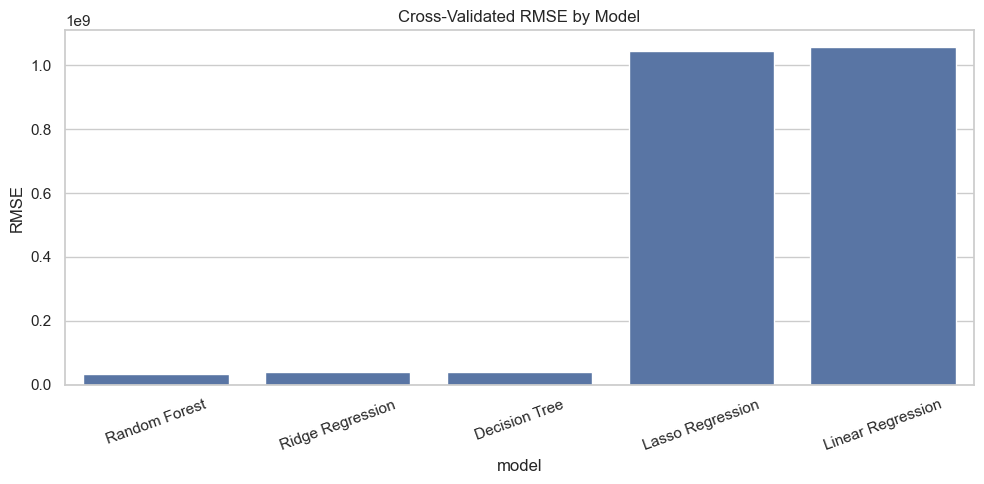

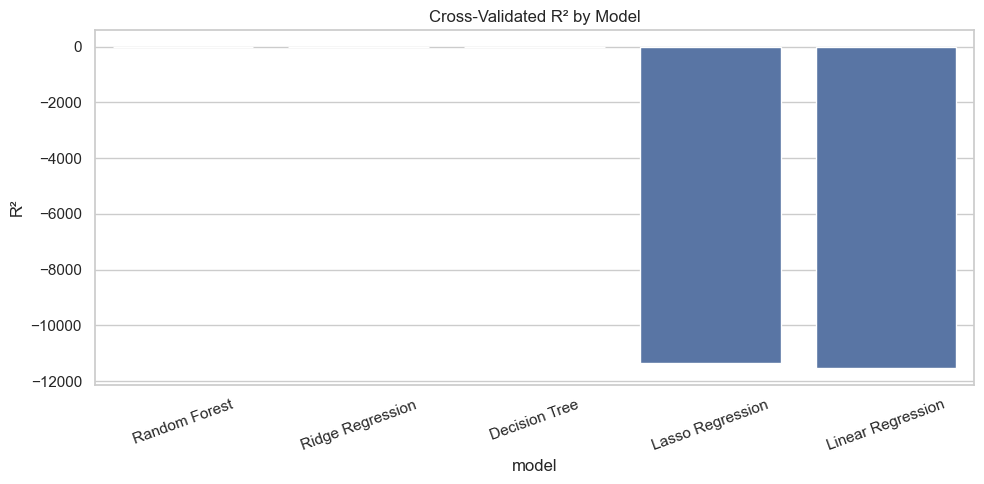

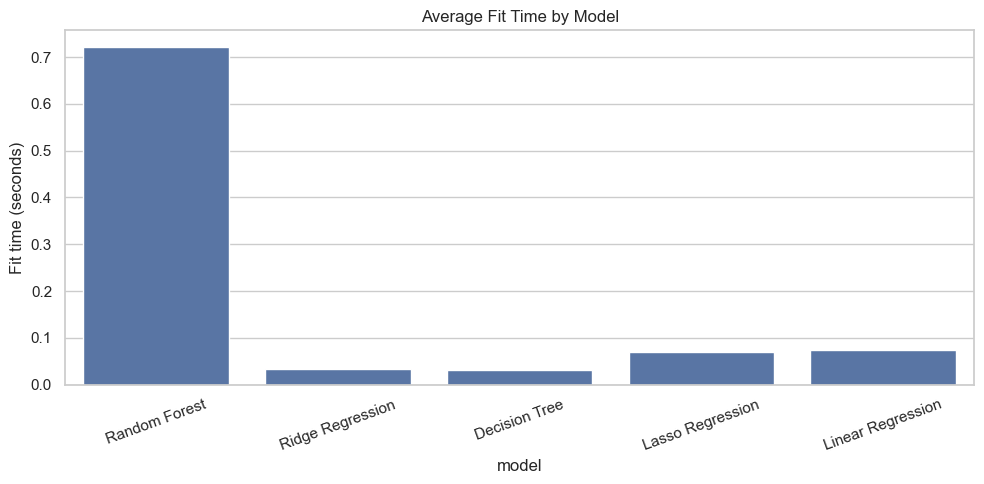

In [26]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="model", y="cv_rmse_mean")
plt.title("Cross-Validated RMSE by Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="model", y="cv_r2_mean")
plt.title("Cross-Validated R² by Model")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="model", y="fit_time_mean_sec")
plt.title("Average Fit Time by Model")
plt.ylabel("Fit time (seconds)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Model selection logic

The best model is selected primarily by:
1. **lowest cross-validated RMSE**
2. then **lowest MAE**
3. then **better computational efficiency**

That matches the problem statement well because price prediction quality is the main goal, but runtime still matters.

In [27]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = make_model_pipeline(best_model_name)

print("Selected best model:", best_model_name)

Selected best model: Random Forest


## 10. Fit the best model on a holdout split for final inspection

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model.fit(X_train, y_train)
test_pred = best_model.predict(X_test)

holdout_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [
        mean_absolute_error(y_test, test_pred),
        np.sqrt(mean_squared_error(y_test, test_pred)),
        r2_score(y_test, test_pred)
    ]
})

display(holdout_metrics)
holdout_metrics.to_csv(TABLE_DIR / "best_model_holdout_metrics.csv", index=False)

,metric,value
0,MAE,1.340024e+07
1,RMSE,3.821962e+07
2,R2,1.716350e-02


In [29]:
pred_df = pd.DataFrame({
    "actual_price": y_test.values,
    "predicted_price": test_pred,
    "absolute_error": np.abs(y_test.values - test_pred)
}).sort_values("absolute_error", ascending=False)

display(pred_df.head(15))
pred_df.to_csv(TABLE_DIR / "best_model_predictions.csv", index=False)

,actual_price,predicted_price,absolute_error
29,270000000.0,1.540975e+07,2.545902e+08
53,95400000.0,8.285736e+06,8.711426e+07
51,90000000.0,1.660318e+07,7.339682e+07
45,58000000.0,2.426989e+07,3.373011e+07
9,44700000.0,1.125403e+07,3.344597e+07
39,30000000.0,8.727642e+06,2.127236e+07
0,20000000.0,4.828994e+03,1.999517e+07
37,20000000.0,4.926280e+03,1.999507e+07
21,41700000.0,2.358696e+07,1.811304e+07
8,34000000.0,1.792096e+07,1.607904e+07


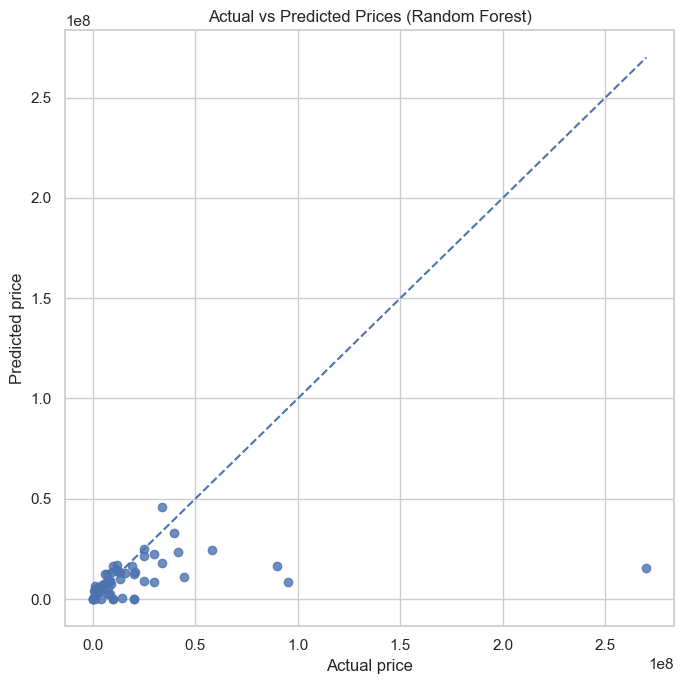

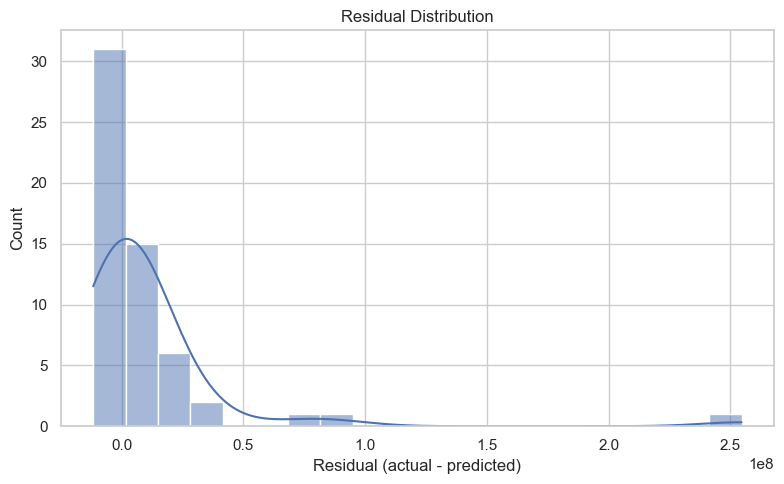

In [30]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_pred, alpha=0.8)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Actual vs Predicted Prices ({best_model_name})")
plt.tight_layout()
plt.show()

residuals = y_test - test_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=20, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (actual - predicted)")
plt.tight_layout()
plt.show()

## 11. Interpret the best model

To keep interpretation consistent across all model families, we use **permutation importance** on the holdout set.  
This measures how much performance drops when each original feature column is shuffled.

,feature,importance_mean,importance_std
7,size_max_sqft,0.099964,0.036703
8,size_mean_sqft,0.092856,0.037734
6,size_min_sqft,0.084513,0.038126
2,city,0.020075,0.043208
0,beds_clean,0.017782,0.026387
5,neighborhood_bucket,0.007264,0.008157
4,property_group,-0.009679,0.018553
9,listing_age_days,-0.011559,0.022898
1,baths_clean,-0.012658,0.014602
3,type,-0.016637,0.021852


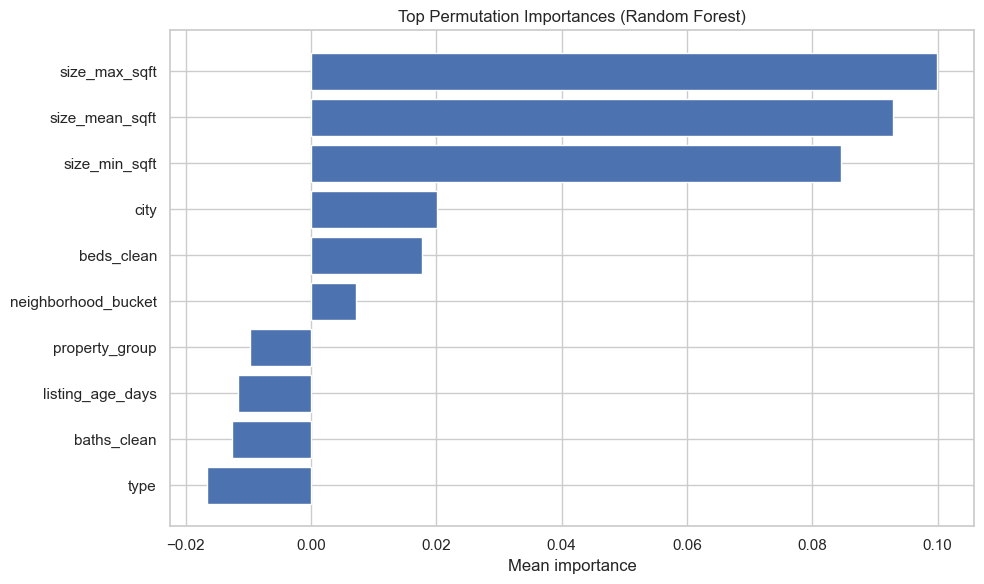

In [31]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df)
importance_df.to_csv(TABLE_DIR / "feature_importance_best_model.csv", index=False)

plt.figure(figsize=(10, 6))
top_imp = importance_df.head(10).sort_values("importance_mean", ascending=True)
plt.barh(top_imp["feature"], top_imp["importance_mean"])
plt.title(f"Top Permutation Importances ({best_model_name})")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.show()

## 12. Save the fitted best model

In [32]:
joblib.dump(best_model, MODEL_DIR / "best_model.joblib")
print("Saved best model to:", (MODEL_DIR / "best_model.joblib").resolve())

Saved best model to: C:\Users\garim\OneDrive\Desktop\Real-Estate-Price-Drivers-Analysis\notebooks\outputs\models\best_model.joblib


## 13. Final conclusions template

After you run the notebook, summarize your findings in plain English. A good structure is:

1. **Data quality**
   - Mention duplicate URLs, 0-value bedroom/bathroom entries, and unstructured size/date fields.

2. **Feature engineering**
   - Mention converting `size` into numeric area features and `date` into listing recency.

3. **Modeling**
   - Mention that five sklearn-compatible models were compared with 5-fold cross-validation.

4. **Best model**
   - State which model achieved the best RMSE / MAE / R².
   - Mention runtime differences if relevant.

5. **Key price drivers**
   - Mention the most important features from permutation importance, likely including size and location variables.

6. **Limitation**
   - The dataset is relatively small and city coverage is uneven, so conclusions should be treated as a baseline rather than a production-grade valuation system.